In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q transformers scipy torch-geometric networkx

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step1 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP1_OUTPUT = f"{DRIVE_BASE}/extension_data/step_embeddings_gt.pkl"
    LOCAL_STEP1_OUTPUT = "extension_data/step_embeddings_gt.pkl"

    if os.path.exists(DRIVE_STEP1_OUTPUT) and not os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Copying step1 output from Drive...")
        !cp "{DRIVE_STEP1_OUTPUT}" "{LOCAL_STEP1_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Step1 output already exists locally.")
    else:
        print("WARNING: Step1 output not found. Run extension_step1 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 941, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 941 (delta 112), reused 99 (delta 91), pack-reused 786 (from 2)
Receiving objects: 100% (941/941), 97.24 MiB | 19.83 MiB/s, done.
Resolving deltas: 100% (502/502), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 16.52 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

In [2]:
import json
import pickle
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Data and Task Graphs

In [3]:
# Load processed step embeddings from Substep 1.
#
# Substep 1 writes one file per boundary source and both are loaded here, so the whole
# notebook runs once and produces a realized graph set for each:
#
# 'gt'           - step boundaries from the annotations. The boundaries are an oracle:
#                  the annotation lists only steps that were actually performed, so the
#                  number of segments is itself informative about the label.
# 'actionformer' - boundaries from the official pre-trained ActionFormer predictions,
#                  covering fewer recordings. Here the segment count comes from a
#                  detector, so a missed detection and a skipped step look the same.
#
# Everything downstream is computed per source; PRIMARY_SOURCE names the one used for
# the single-graph illustrations and the encoder diagnostic.

_SOURCE_FILES = {'gt': 'step_embeddings_gt.pkl',
                 'actionformer': 'step_embeddings_actionformer.pkl'}


def _resolve(filename):
    """Prefer the Drive copy in Colab, fall back to the local extension_data folder."""
    if IN_COLAB:
        drive = "/content/drive/MyDrive/AML_Project/extension_data/" + filename
        if os.path.exists(drive):
            return drive
    local = os.path.join("extension_data", filename)
    return local if os.path.exists(local) else None


SOURCE_DATA, SOURCE_SPLITS = {}, {}
for _source, _filename in _SOURCE_FILES.items():
    _path = _resolve(_filename)
    if _path is None:
        print(f"  {_source:<14} not found ({_filename}) - skipped")
        continue
    with open(_path, 'rb') as f:
        _loaded = pickle.load(f)
    SOURCE_DATA[_source] = _loaded['data']
    SOURCE_SPLITS[_source] = _loaded['splits']
    print(f"  {_source:<14} {len(_loaded['data']):>3} recordings   {_path}")

assert SOURCE_DATA, "No step embeddings found. Run extension_step1_actionformer.ipynb first."

SOURCES = list(SOURCE_DATA)
PRIMARY_SOURCE = 'gt' if 'gt' in SOURCE_DATA else SOURCES[0]
processed_data = SOURCE_DATA[PRIMARY_SOURCE]
splits = SOURCE_SPLITS[PRIMARY_SOURCE]
print(f"\nSources: {SOURCES}   primary: {PRIMARY_SOURCE}")

# Load step annotations for textual descriptions
with open('annotations/annotation_json/step_annotations.json', 'r') as f:
    step_annotations = json.load(f)


  gt             383 recordings   /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl
  actionformer   119 recordings   /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_actionformer.pkl

Sources: ['gt', 'actionformer']   primary: gt


In [4]:
# Task graph annotations (from CaptainCook4D).
#
# The dataset ships one task graph per recipe in annotations/task_graphs/, and these are
# genuine DAGs: preparation steps that may happen in any order sit on parallel branches
# and merge at the step that consumes them. Across the 24 recipes, 18 contain a
# branching node, 23 contain a merge, and 20 have more than one root, so the topology
# carries real procedural information that a linear ordering does not.
#
# The files are keyed by recipe name and number their steps locally (0 = START,
# last = END), while every other annotation file keys steps by a global step_id. The two
# are reconciled here on the step descriptions, which are byte-identical in both sources.

import glob
import re

TASK_GRAPH_DIR = "annotations/task_graphs"


def _norm_description(text):
    return re.sub(r'[^a-z0-9]', '', text.lower())


def load_captaincook_task_graphs(step_annotations, graph_dir=TASK_GRAPH_DIR):
    """Load the shipped per-recipe DAGs and re-key them by activity id.

    Returns None if any recipe fails to match a file, so that the caller falls back
    visibly rather than silently mixing two different graph definitions.
    """
    files = sorted(glob.glob(os.path.join(graph_dir, "*.json")))
    if not files:
        return None

    parsed = []
    for path in files:
        with open(path, 'r') as f:
            raw = json.load(f)
        steps = {k: v for k, v in raw['steps'].items() if v not in ('START', 'END')}
        parsed.append((os.path.basename(path)[:-5], steps, raw['edges']))

    # global step_id -> description, per activity, taken from the annotations
    annotated = defaultdict(dict)
    for recording_id, ann in step_annotations.items():
        activity = recording_id.split('_')[0]
        for step in ann.get('steps', []):
            sid, desc = step.get('step_id'), step.get('description', '')
            if sid and desc:
                annotated[activity].setdefault(sid, desc)

    graphs = {}
    for activity, id_to_desc in annotated.items():
        global_of_norm = {_norm_description(d): sid for sid, d in id_to_desc.items()}

        best = (0.0, None)
        for name, steps, edges in parsed:
            overlap = (sum(1 for v in steps.values()
                           if _norm_description(v) in global_of_norm)
                       / max(1, len(id_to_desc)))
            if overlap > best[0]:
                best = (overlap, (name, steps, edges))

        if best[0] < 0.9:
            print(f"  activity {activity}: no task graph matched (best overlap {best[0]:.2f})")
            return None

        name, steps, raw_edges = best[1]
        global_of_local = {k: global_of_norm[_norm_description(v)] for k, v in steps.items()}

        # A few recipes list the same step twice (a stir repeated later in the
        # procedure). The annotations give both occurrences one step_id, so they are one
        # canonical node here and the two occurrences' edges are unioned onto it.
        global_ids = sorted(set(global_of_local.values()))
        index_of_global = {gid: i for i, gid in enumerate(global_ids)}
        index_of_local = {local: index_of_global[gid] for local, gid in global_of_local.items()}
        description_of_global = {gid: steps[local] for local, gid in global_of_local.items()}

        seen, edges = set(), []
        for a, b in raw_edges:
            a, b = str(a), str(b)
            # Edges touching START/END are dropped: those have no visual counterpart.
            if a not in index_of_local or b not in index_of_local:
                continue
            src, dst = index_of_local[a], index_of_local[b]
            if src == dst or (src, dst) in seen:
                continue
            seen.add((src, dst))
            edges.append({'from': src, 'to': dst})

        graphs[activity] = {
            'recipe_id': activity,
            'source_file': name,
            'nodes': [{'step_id': gid, 'description': description_of_global[gid], 'index': i}
                      for i, gid in enumerate(global_ids)],
            'edges': edges,
        }

    return graphs


task_graphs = load_captaincook_task_graphs(step_annotations)

if task_graphs is not None:
    _n_nodes = sum(len(g['nodes']) for g in task_graphs.values())
    _n_edges = sum(len(g['edges']) for g in task_graphs.values())
    print(f"Loaded {len(task_graphs)} task graphs from {TASK_GRAPH_DIR}")
    print(f"  {_n_nodes} nodes, {_n_edges} edges; a linear chain over the same nodes "
          f"would have {_n_nodes - len(task_graphs)}")
else:
    print(f"No usable task graphs under {TASK_GRAPH_DIR}.")
    print("Falling back to a linear chain built from the step annotations. The chain "
          "orders steps by step_id, which is NOT the dependency order, so the graph "
          "structure below is not the dataset's procedural structure.")

Loaded 24 task graphs from annotations/task_graphs
  353 nodes, 369 edges; a linear chain over the same nodes would have 329


In [5]:
# Fallback only: build a linear task graph from the step annotations.
#
# This runs when the shipped DAGs above could not be loaded. It orders each recipe's
# steps by step_id and links consecutive pairs. step_id order is not dependency
# order, so the edges are an arbitrary chain rather than the recipe's procedural
# structure. The node set is identical either way; only the topology differs.

def build_task_graphs_from_annotations(step_annotations):
    """
    Build task graphs from step annotations.
    Each recipe type (activity_id) has a canonical set of steps.

    Note: activity_id is extracted from recording_id prefix (format: X_Y where X is activity/recipe number)
    """
    recipe_steps = defaultdict(dict)

    for recording_id, ann in step_annotations.items():
        # Extract recipe_id from recording_id prefix (format: "X_Y" where X is activity number)
        recipe_id = recording_id.split('_')[0] if '_' in recording_id else 'unknown'

        for step in ann.get('steps', []):
            step_id = step.get('step_id')
            description = step.get('description', '')

            if step_id and description:
                # Keep the most common/complete description
                if step_id not in recipe_steps[recipe_id]:
                    recipe_steps[recipe_id][step_id] = description

    # Convert to task graph format
    task_graphs = {}
    for recipe_id, steps in recipe_steps.items():
        sorted_steps = sorted(steps.items(), key=lambda x: x[0])

        task_graphs[recipe_id] = {
            'recipe_id': recipe_id,
            'nodes': [
                {'step_id': sid, 'description': desc, 'index': i}
                for i, (sid, desc) in enumerate(sorted_steps)
            ],
            'edges': [
                {'from': i, 'to': i+1}
                for i in range(len(sorted_steps) - 1)
            ]
        }

    return task_graphs

if task_graphs is None:
    task_graphs = build_task_graphs_from_annotations(step_annotations)

_edge_total = sum(len(g["edges"]) for g in task_graphs.values())
print(f"Task graphs for {len(task_graphs)} recipe types, {_edge_total} edges")
for recipe_id, graph in list(task_graphs.items())[:3]:
    print(f"  Recipe {recipe_id}: {len(graph['nodes'])} steps")

Task graphs for 24 recipe types, 369 edges
  Recipe 1: 12 steps
  Recipe 2: 14 steps
  Recipe 3: 14 steps


## 2. EgoVLP Text Encoder (Aligned with Visual Features)

We load the EgoVLP model and use its text encoder.

In [6]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer
import sys
import os
import shutil
import urllib.request

# Determine feature dimension from loaded data
sample_key = list(processed_data.keys())[0]
FEATURE_DIM = processed_data[sample_key]['step_embeddings'].shape[1]
print(f"Visual feature dimension: {FEATURE_DIM}")

# ==============================================================================
# Strict EgoVLP Loading with Helper Checks
# ==============================================================================
EGOVLP_AVAILABLE = False

try:
    # 1. Clone EgoVLP repository directly
    EGOVLP_PATH = "EgoVLP"
    if not os.path.exists(EGOVLP_PATH):
        print("Cloning EgoVLP repository...")
        !git clone https://github.com/showlab/EgoVLP.git {EGOVLP_PATH}

    print("Installing EgoVLP dependencies...")
    # Added 'av', 'decord', and 'ffmpeg-python' to the requirements
    !pip install -q timm ftfy einops av decord ffmpeg-python

    # 2. Add to system path
    if EGOVLP_PATH not in sys.path:
        sys.path.insert(0, EGOVLP_PATH)

    # ==========================================================================
    # Fix for missing ViT backbone
    # ==========================================================================
    # The model code expects 'pretrained/jx_vit_base_p16_224-80ecf9dd.pth' to exist locally
    if not os.path.exists("pretrained"):
        os.makedirs("pretrained")

    vit_checkpoint_path = "pretrained/jx_vit_base_p16_224-80ecf9dd.pth"
    if not os.path.exists(vit_checkpoint_path):
        print(f"Downloading missing ViT backbone to {vit_checkpoint_path}...")
        vit_url = "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-vitjx/jx_vit_base_p16_224-80ecf9dd.pth"
        urllib.request.urlretrieve(vit_url, vit_checkpoint_path)
        print("Download complete.")

    # 3. Locate Main EgoVLP Checkpoint (Drive or Local)
    CKPT_FILENAME = "egovlp.pth"

    # Define paths to search
    search_paths = [
        "pretrained/egovlp.pth",  # Local
        f"/content/drive/MyDrive/AML_Project/pretrained/{CKPT_FILENAME}"  # Drive
    ]

    # Check if we are in Colab to define Drive path creation
    if 'IN_COLAB' in globals() and IN_COLAB:
        DRIVE_PRETRAINED_DIR = "/content/drive/MyDrive/AML_Project/pretrained"
        os.makedirs(DRIVE_PRETRAINED_DIR, exist_ok=True)
        print(f"Ensured directory exists: {DRIVE_PRETRAINED_DIR}")

    # Find the checkpoint
    EGOVLP_CKPT = None
    for path in search_paths:
        if os.path.exists(path):
            EGOVLP_CKPT = path
            print(f"Found checkpoint at: {EGOVLP_CKPT}")
            break

    # If not found, raise helpful error
    if EGOVLP_CKPT is None:
        error_msg = (
            f"\n{'='*60}\n"
            f"CRITICAL: EgoVLP checkpoint '{CKPT_FILENAME}' not found!\n"
            f"{'='*60}\n"
            f"Please follow these steps:\n"
            f"1. Go to the official EgoVLP repo: https://github.com/showlab/EgoVLP\n"
            f"2. Download the 'Ego4D' pretrained model from their Model Zoo.\n"
            f"3. Rename the file to '{CKPT_FILENAME}'.\n"
            f"4. Upload it to this Google Drive folder: /AML_Project/pretrained/\n"
            f"   (Full path: /content/drive/MyDrive/AML_Project/pretrained/{CKPT_FILENAME})\n"
            f"\nAlternatively, you can upload it to the local Colab folder: pretrained/\n"
            f"{'='*60}\n"
        )
        raise FileNotFoundError(error_msg)

    # Check for model module availability
    try:
        from model.model import FrozenInTime
    except ImportError:
            print("Could not import FrozenInTime despite path insertion. Re-checking dependencies...")
            !pip install -q timm ftfy einops av decord ffmpeg-python
            from model.model import FrozenInTime

    # Load EgoVLP config
    egovlp_config = {
        "video_params": {
            "model": "SpaceTimeTransformer",
            "arch_config": "base_patch16_224",
            "num_frames": 16,      # UPDATED: Changed from 4 to 16 to match checkpoint
            "pretrained": False,
            "time_init": "zeros"
        },
        "text_params": {
            "model": "distilbert-base-uncased",
            "pretrained": True,
            "input": "text"
        },
        "projection": "minimal",
        "projection_dim": 256,
        "load_checkpoint": ""  # Bypass internal loading
    }

    # Initialize model
    print("Loading EgoVLP model structure...")

    # Fix for LOCAL_RANK error
    if 'LOCAL_RANK' not in os.environ:
        os.environ['LOCAL_RANK'] = '0'

    egovlp_model = FrozenInTime(**egovlp_config)

    # Load checkpoint manually
    print(f"Loading weights from {EGOVLP_CKPT}...")

    try:
        # Try loading with weights_only=False (needed for older checkpoints with ConfigParser)
        checkpoint = torch.load(EGOVLP_CKPT, map_location='cpu', weights_only=False)
    except TypeError:
        # Fallback for older torch versions without this arg
        checkpoint = torch.load(EGOVLP_CKPT, map_location='cpu')

    state_dict = checkpoint.get('state_dict', checkpoint)

    # Remove 'module.' prefix if present
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '') if k.startswith('module.') else k
        new_state_dict[new_key] = v

    # strict=False silently leaves any parameter that is ABSENT from the checkpoint at
    # its random initialisation, and prints nothing. The text branch (text_model.* and
    # txt_proj.*) is exactly what this notebook depends on: if txt_proj stayed random,
    # encode_texts() would return a random projection of DistilBERT features, which is
    # not the space the EgoVLP visual features live in, and every cosine similarity
    # computed below would be meaningless. So check what actually loaded.
    load_report = egovlp_model.load_state_dict(new_state_dict, strict=False)
    TEXT_BRANCH_MISSING = [k for k in load_report.missing_keys
                           if k.startswith('text_model') or k.startswith('txt_proj')]
    print(f"Checkpoint load: {len(load_report.missing_keys)} missing key(s), "
          f"{len(load_report.unexpected_keys)} unexpected key(s)")
    if TEXT_BRANCH_MISSING:
        print("*" * 72)
        print(f"WARNING: {len(TEXT_BRANCH_MISSING)} text-branch parameter(s) were NOT in "
              f"the checkpoint and are still randomly initialised:")
        for k in TEXT_BRANCH_MISSING[:10]:
            print(f"    {k}")
        print("Text embeddings are therefore NOT aligned with the visual features.")
        print("*" * 72)
    else:
        print("Text branch (text_model.* + txt_proj.*) fully loaded from the checkpoint.")
    egovlp_model = egovlp_model.to(device)
    egovlp_model.eval()

    EGOVLP_AVAILABLE = True
    print("\u2713 EgoVLP text encoder loaded successfully!")

    # Initialize tokenizer globally
    print("Loading Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

except Exception as e:
    print(f"CRITICAL ERROR: Could not load EgoVLP.\n{e}")
    raise RuntimeError("EgoVLP is required but failed to load. Stopping execution.") from e


# ==============================================================================
# Text Encoding Function (EgoVLP Only)
# ==============================================================================

def encode_texts(texts, normalize=True):
    """
    Encode text descriptions using EgoVLP.
    """
    with torch.no_grad():
        # Tokenize text
        inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)

        # Move to device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Compute embeddings
        # Note: EgoVLP compute_text expects the dictionary of inputs directly
        text_embeddings = egovlp_model.compute_text(inputs)

    if normalize:
        text_embeddings = F.normalize(text_embeddings, p=2, dim=-1)

    return text_embeddings


# Test the encoder
print("\nTesting text encoder...")
test_texts = ["Break the eggs", "Mix the ingredients", "Heat the pan"]
with torch.no_grad():
    test_emb = encode_texts(test_texts)
print(f"Test text embeddings shape: {test_emb.shape}")
print(f"Alignment method: EgoVLP (Strict)")

Visual feature dimension: 256
Cloning EgoVLP repository...
Cloning into 'EgoVLP'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 268 (delta 67), reused 57 (delta 57), pack-reused 182 (from 1)
Receiving objects: 100% (268/268), 1.99 MiB | 29.53 MiB/s, done.
Resolving deltas: 100% (120/120), done.
Installing EgoVLP dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 81.3 MB/s eta 0:00:00
Download complete.
Ensured directory exists: /content/drive/MyDrive/AML_Project/pretrained
Found checkpoint at: /content/drive/MyDrive/AML_Project/pretrained/egovlp.pth
Loading EgoVLP model structure...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Testing text encoder...
Test text embeddings shape: torch.Size([3, 256])
Alignment method: EgoVLP (Strict)


In [7]:
# ==============================================================================
# DIAGNOSTIC: is the EgoVLP text encoder really aligned with our visual features?
# ==============================================================================
# Everything in this notebook rests on one assumption: EgoVLP's video and text
# encoders share a joint space, so cosine similarity between a visual step embedding
# and a step description is meaningful. That assumption is measured here, not assumed.
#
# Test: for each recording, encode that recording's OWN step descriptions and match
# them against its OWN visual step embeddings. Step i's video should retrieve step i's
# description. If the two encoders share a space, top-1 accuracy sits far above chance
# and the correct pair scores clearly higher than a wrong pair.

import numpy as np


def _valid_steps(recording_id):
    """Step dicts in the same order Substep 1 used (negative timestamps dropped).

    Substep 1 skips steps with a negative start/end time ("missing steps"), so the raw
    annotation list is NOT index-aligned with step_embeddings. Any code that pairs an
    embedding with a description has to apply the same filter.
    """
    out = []
    for s in step_annotations.get(recording_id, {}).get('steps', []):
        st, et = s.get('start_time'), s.get('end_time')
        if st is None or et is None or float(st) < 0 or float(et) < 0:
            continue
        out.append(s)
    return out


rng = np.random.default_rng(0)
sample_ids = list(processed_data.keys())
rng.shuffle(sample_ids)
sample_ids = sample_ids[:100]

n_used = n_skipped = 0
hits = total = 0
chance_sum = 0.0
self_sims, other_sims = [], []

for rid in sample_ids:
    vis = processed_data[rid]['step_embeddings']
    descs = [s.get('description', '') for s in _valid_steps(rid)]

    # Only usable when descriptions line up 1:1 with the embeddings.
    if len(descs) != len(vis) or len(descs) < 2 or not all(descs):
        n_skipped += 1
        continue
    n_used += 1

    txt = encode_texts(descs, normalize=True).cpu().numpy()
    v = vis / (np.linalg.norm(vis, axis=1, keepdims=True) + 1e-8)
    sim = v @ txt.T                    # (n, n); the diagonal is the correct pairing

    n = len(descs)
    hits += int((sim.argmax(axis=1) == np.arange(n)).sum())
    total += n
    chance_sum += 1.0                  # one expected hit per recording by chance

    eye = np.eye(n, dtype=bool)
    self_sims.extend(sim[eye].tolist())
    other_sims.extend(sim[~eye].tolist())

print(f"Recordings used: {n_used}  (skipped {n_skipped}: description/embedding mismatch)")

if total == 0:
    print("No usable recordings - cannot evaluate alignment.")
else:
    margin = np.mean(self_sims) - np.mean(other_sims)
    print(f"Step pairs evaluated: {total}")
    print()
    print(f"  video->text top-1 retrieval : {100 * hits / total:.2f}%")
    print(f"  chance                      : {100 * chance_sum / total:.2f}%")
    print()
    print(f"  mean cosine, correct pair   : {np.mean(self_sims):.4f}")
    print(f"  mean cosine, wrong pair     : {np.mean(other_sims):.4f}")
    print(f"  margin (correct - wrong)    : {margin:+.4f}")
    print()
    if margin < 0.02:
        print("VERDICT: no usable alignment. Hungarian matching on this similarity is")
        print("essentially arbitrary, and the matching step carries no real signal.")
    else:
        print("VERDICT: the encoders are aligned; matching is measuring something real.")


Recordings used: 100  (skipped 0: description/embedding mismatch)
Step pairs evaluated: 1399

  video->text top-1 retrieval : 27.31%
  chance                      : 7.15%

  mean cosine, correct pair   : 0.3393
  mean cosine, wrong pair     : 0.2276
  margin (correct - wrong)    : +0.1117

VERDICT: the encoders are aligned; matching is measuring something real.


## 3. Encode Task Graph Nodes

In [8]:
def encode_task_graph_nodes(task_graph):
    """
    Encode all nodes in a task graph using the EgoVLP text encoder.

    Uses the encode_texts function which leverages EgoVLP for aligned
    text-visual embeddings (or falls back to sentence-transformers).

    Returns:
        node_embeddings: numpy array of shape (num_nodes, feature_dim)
        node_info: list of node metadata
    """
    nodes = task_graph['nodes']
    descriptions = [node['description'] for node in nodes]

    # Use the unified encode_texts function (EgoVLP or fallback)
    node_embeddings = encode_texts(descriptions, normalize=True)

    return node_embeddings.cpu().numpy(), nodes

# Encode all task graphs
print("Encoding task graph nodes...")
task_graph_embeddings = {}

for recipe_id, graph in tqdm(task_graphs.items(), desc="Encoding graphs"):
    embeddings, nodes = encode_task_graph_nodes(graph)
    task_graph_embeddings[recipe_id] = {
        'embeddings': embeddings,
        'nodes': nodes,
        'edges': graph['edges']
    }

print(f"Encoded {len(task_graph_embeddings)} task graphs")
print(f"Using {'EgoVLP (aligned)' if EGOVLP_AVAILABLE else 'Sentence-BERT (approximate)'} text encoder")

Encoding task graph nodes...


Encoding graphs: 100%|██████████| 24/24 [00:00<00:00, 69.74it/s]

Encoded 24 task graphs
Using EgoVLP (aligned) text encoder


## 4. Hungarian Matching

Match visual step embeddings to task graph nodes using the Hungarian algorithm.
This ensures one-to-one matching between observed steps and graph nodes.

In [9]:
def compute_similarity_matrix(visual_embeddings, text_embeddings):
    """
    Compute cosine similarity matrix between visual and text embeddings.

    Args:
        visual_embeddings: (num_visual, feature_dim)
        text_embeddings: (num_text, feature_dim)

    Returns:
        similarity: (num_visual, num_text)
    """
    # Normalize
    visual_norm = visual_embeddings / (np.linalg.norm(visual_embeddings, axis=1, keepdims=True) + 1e-8)
    text_norm = text_embeddings / (np.linalg.norm(text_embeddings, axis=1, keepdims=True) + 1e-8)

    # Cosine similarity
    similarity = np.dot(visual_norm, text_norm.T)

    return similarity


def hungarian_matching(visual_embeddings, text_embeddings):
    """
    Perform Hungarian matching between visual steps and task graph nodes.

    Args:
        visual_embeddings: (num_visual, feature_dim)
        text_embeddings: (num_text, feature_dim)

    Returns:
        matches: list of (visual_idx, text_idx, similarity) tuples
        unmatched_visual: indices of unmatched visual steps
        unmatched_text: indices of unmatched text nodes
    """
    num_visual = len(visual_embeddings)
    num_text = len(text_embeddings)

    # Compute similarity (higher is better)
    similarity = compute_similarity_matrix(visual_embeddings, text_embeddings)

    # Convert to cost (lower is better) for Hungarian algorithm
    cost = -similarity

    # Pad if sizes don't match
    if num_visual != num_text:
        max_size = max(num_visual, num_text)
        padded_cost = np.full((max_size, max_size), 0.0)  # Neutral cost for padding
        padded_cost[:num_visual, :num_text] = cost
        cost = padded_cost

    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(cost)

    # Extract valid matches
    matches = []
    matched_visual = set()
    matched_text = set()

    for v_idx, t_idx in zip(row_ind, col_ind):
        if v_idx < num_visual and t_idx < num_text:
            sim = similarity[v_idx, t_idx]
            matches.append((v_idx, t_idx, sim))
            matched_visual.add(v_idx)
            matched_text.add(t_idx)

    unmatched_visual = [i for i in range(num_visual) if i not in matched_visual]
    unmatched_text = [i for i in range(num_text) if i not in matched_text]

    return matches, unmatched_visual, unmatched_text

In [10]:
# Test Hungarian matching on a sample
sample_recording = list(processed_data.keys())[0]
sample_data = processed_data[sample_recording]
# Convert to string to match dictionary keys
sample_recipe = str(sample_data['recipe_id'])

if sample_recipe in task_graph_embeddings:
    visual_emb = sample_data['step_embeddings']
    text_emb = task_graph_embeddings[sample_recipe]['embeddings']
    nodes = task_graph_embeddings[sample_recipe]['nodes']

    matches, unmatched_v, unmatched_t = hungarian_matching(visual_emb, text_emb)

    print(f"Recording: {sample_recording}")
    print(f"Recipe: {sample_recipe}")
    print(f"Visual steps: {len(visual_emb)}, Graph nodes: {len(text_emb)}")
    print(f"Matches: {len(matches)}")
    # The printed description must come from the SAME filtered step list Substep 1 used.
    # Indexing the raw annotation list includes negative-timestamp "missing steps" that
    # have no embedding, which shifts every label after the first missing step and makes
    # the printout look like a mismatch even when the matching is fine.
    visual_steps = _valid_steps(sample_recording)
    if len(visual_steps) != len(visual_emb):
        print(f"  [warn] {len(visual_steps)} descriptions vs {len(visual_emb)} embeddings"
              f" - labels below are not reliable for this recording")

    print(f"\nTop matches:")
    for v_idx, t_idx, sim in sorted(matches, key=lambda x: -x[2])[:5]:
        if v_idx < len(visual_steps) == len(visual_emb):
            visual_desc = visual_steps[v_idx].get('description', f"Step {v_idx}")
        else:
            visual_desc = f"Step {v_idx}"

        visual_desc = str(visual_desc)[:50]
        text_desc = nodes[t_idx]['description'][:50]
        print(f"  Visual: '{visual_desc}...' -> Graph: '{text_desc}...' (sim={sim:.3f})")
else:
    print(f"Recipe ID {sample_recipe} (type: {type(sample_recipe)}) not found in task_graphs keys: {list(task_graph_embeddings.keys())[:5]}")

Recording: 1_19
Recipe: 1
Visual steps: 12, Graph nodes: 12
Matches: 12

Top matches:
  Visual: 'Microwave -Microwave just until cheese melts, abou...' -> Graph: 'Microwave -Continue to Microwave for 15-30 more se...' (sim=0.615)
  Visual: 'Microwave-Microwave the ramekin cup uncovered on h...' -> Graph: 'Microwave-Microwave the ramekin cup uncovered on h...' (sim=0.521)
  Visual: 'Microwave -Continue to Microwave for 15-30 more se...' -> Graph: 'Microwave -Microwave just until cheese melts, abou...' (sim=0.479)
  Visual: 'stir-stir the ramekin cup...' -> Graph: 'stir-stir the ramekin cup...' (sim=0.428)
  Visual: 'sprinkle -sprinkle 1 tablespoon of cheese on cup...' -> Graph: 'sprinkle -sprinkle 1 tablespoon of cheese on cup...' (sim=0.407)


## 5. Create Realized Task Graphs

For each recording, create a "realized" task graph by:
1. Matching visual steps to graph nodes with the Hungarian algorithm
2. Storing the matched visual embedding **alongside** the node's text embedding

The spec asks to *"update the features of the matched nodes with a learnable projection
of the node features and the visual features."* That projection is deliberately **not**
applied here: this notebook has no loss function, so a projector instantiated here could
never be trained and would just apply a random transform. The two feature sets are kept
separate and the projection lives inside the Substep 4 GNN, where the classification
loss can actually train it. A fixed `0.5*visual + 0.5*text` average is still saved as
`node_features` so Substep 4 can report it as the no-projection baseline.

In [11]:
def create_realized_graph(recording_data, task_graph_emb):
    """
    Create a realized task graph by matching visual steps to task graph nodes.

    Node features are kept SEPARATE (text and visual) instead of being combined here,
    so that Substep 4 can learn the projection the spec asks for. See the markdown
    cell above for why the projection cannot be trained in this notebook.

    Returns:
        realized_graph: dict with
            - node_text_features:   (num_nodes, D) task-graph node text embeddings
            - node_visual_features: (num_nodes, D) matched visual step embedding,
                                    zeros for unmatched nodes
            - node_features:        (num_nodes, D) fixed 0.5/0.5 average of the two,
                                    kept only as the no-projection baseline
            - edge_index:           (2, num_edges) COO format for PyG
            - node_matched:         boolean mask over nodes
            - match_similarities:   cosine similarity of each node's match, 0 if unmatched
    """
    visual_emb = recording_data['step_embeddings']
    text_emb = task_graph_emb['embeddings']
    nodes = task_graph_emb['nodes']
    edges = task_graph_emb['edges']

    num_nodes = len(nodes)

    # Perform matching
    matches, unmatched_v, unmatched_t = hungarian_matching(visual_emb, text_emb)

    node_text_features = np.asarray(text_emb, dtype=np.float32).copy()
    node_visual_features = np.zeros_like(node_text_features)
    # Unmatched nodes keep their text embedding in the baseline feature set.
    node_features = node_text_features.copy()
    node_matched = np.zeros(num_nodes, dtype=bool)
    match_similarities = np.zeros(num_nodes)

    for v_idx, t_idx, sim in matches:
        node_matched[t_idx] = True
        match_similarities[t_idx] = sim
        node_visual_features[t_idx] = visual_emb[v_idx]
        node_features[t_idx] = 0.5 * visual_emb[v_idx] + 0.5 * text_emb[t_idx]

    # Convert edges to COO format
    if len(edges) > 0:
        edge_src = [e['from'] for e in edges]
        edge_dst = [e['to'] for e in edges]
        edge_index = np.array([edge_src, edge_dst])
    else:
        edge_index = np.zeros((2, 0), dtype=int)

    return {
        'node_text_features': node_text_features,
        'node_visual_features': node_visual_features,
        'node_features': node_features,
        'edge_index': edge_index,
        'node_matched': node_matched,
        'match_similarities': match_similarities,
        'num_matches': len(matches),
        'num_nodes': num_nodes,
        'num_visual_steps': len(visual_emb)
    }

In [12]:
# Build realized task graphs for every boundary source.
#
# The task graph encoding above is shared: the node text and its embedding do not
# depend on how the video was segmented. Only the Hungarian matching is redone per
# source, which is why running both costs almost nothing over running one.

REALIZED_BY_SOURCE = {}

for source in SOURCES:
    graphs, missing = {}, []
    for recording_id, data in tqdm(SOURCE_DATA[source].items(), desc=f"{source:>13}"):
        recipe_id = str(data['recipe_id'])
        if recipe_id not in task_graph_embeddings:
            missing.append(recording_id)
            continue

        realized = create_realized_graph(data, task_graph_embeddings[recipe_id])
        realized['recipe_label'] = data['recipe_label']
        realized['recipe_id'] = recipe_id
        graphs[recording_id] = realized

    REALIZED_BY_SOURCE[source] = graphs
    ratios = [g['num_matches'] / g['num_nodes'] for g in graphs.values()]
    print(f"  {source:<14} {len(graphs):>3} graphs   "
          f"mean match ratio {np.mean(ratios):.2%}   "
          f"missing task graph: {len(missing)}")

realized_graphs = REALIZED_BY_SOURCE[PRIMARY_SOURCE]


           gt: 100%|██████████| 383/383 [00:00<00:00, 1484.88it/s]


  gt             383 graphs   mean match ratio 95.32%   missing task graph: 0


 actionformer: 100%|██████████| 119/119 [00:00<00:00, 1493.72it/s]

  actionformer   119 graphs   mean match ratio 89.54%   missing task graph: 0


## 6. Analyze Matching Quality

source          graphs  mean sim  match ratio  sim | correct  sim | error
-------------------------------------------------------------------------
gt                 383     0.371      95.32%          0.367        0.374
actionformer       119     0.373      89.54%          0.367        0.377



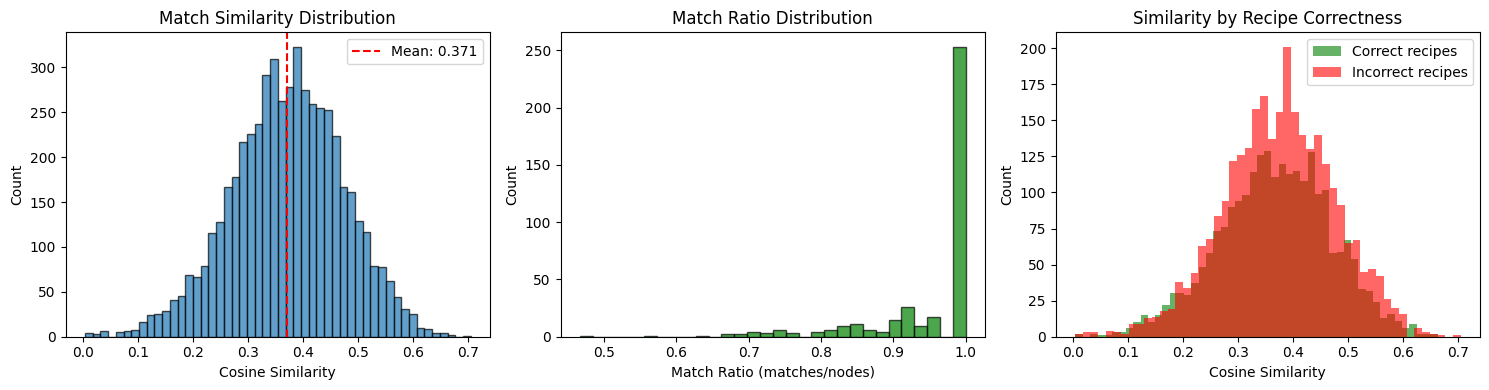


Matching Statistics (gt boundaries):
  Average similarity: 0.371
  Average match ratio: 95.32%
  Correct recipes avg sim: 0.367
  Incorrect recipes avg sim: 0.374


In [13]:
import matplotlib.pyplot as plt

# Numeric summary for every source; the plots below show the primary source only.
print(f"{'source':<14}{'graphs':>8}{'mean sim':>10}{'match ratio':>13}"
      f"{'sim | correct':>15}{'sim | error':>13}")
print("-" * 73)
for _source, _graphs in REALIZED_BY_SOURCE.items():
    _sims, _ratios, _ok, _err = [], [], [], []
    for _g in _graphs.values():
        _s = _g['match_similarities'][_g['node_matched']]
        _sims.extend(_s)
        _ratios.append(_g['num_matches'] / _g['num_nodes'])
        (_ok if _g['recipe_label'] == 0 else _err).extend(_s)
    print(f"{_source:<14}{len(_graphs):>8}{np.mean(_sims):>10.3f}{np.mean(_ratios):>12.2%}"
          f"{np.mean(_ok):>15.3f}{np.mean(_err):>13.3f}")
print()

# Matching statistics
all_similarities = []
match_ratios = []
correct_sims = []
incorrect_sims = []

for g in realized_graphs.values():
    sims = g['match_similarities'][g['node_matched']]
    all_similarities.extend(sims)
    match_ratios.append(g['num_matches'] / g['num_nodes'])

    if g['recipe_label'] == 0:
        correct_sims.extend(sims)
    else:
        incorrect_sims.extend(sims)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Match similarity distribution
axes[0].hist(all_similarities, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Match Similarity Distribution')
axes[0].axvline(np.mean(all_similarities), color='r', linestyle='--',
                label=f'Mean: {np.mean(all_similarities):.3f}')
axes[0].legend()

# Match ratio distribution
axes[1].hist(match_ratios, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Match Ratio (matches/nodes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Match Ratio Distribution')

# Similarity by recipe correctness
axes[2].hist(correct_sims, bins=50, alpha=0.6, label='Correct recipes', color='green')
axes[2].hist(incorrect_sims, bins=50, alpha=0.6, label='Incorrect recipes', color='red')
axes[2].set_xlabel('Cosine Similarity')
axes[2].set_ylabel('Count')
axes[2].set_title('Similarity by Recipe Correctness')
axes[2].legend()

plt.tight_layout()
plt.savefig('extension_data/matching_analysis.png', dpi=150)
plt.show()

print(f"\nMatching Statistics ({PRIMARY_SOURCE} boundaries):")
print(f"  Average similarity: {np.mean(all_similarities):.3f}")
print(f"  Average match ratio: {np.mean(match_ratios):.2%}")
print(f"  Correct recipes avg sim: {np.mean(correct_sims):.3f}")
print(f"  Incorrect recipes avg sim: {np.mean(incorrect_sims):.3f}")

## 7. Save Realized Graphs

In [14]:
# Save realized graphs for Substep 4 - one file per boundary source.
OUTPUT_DIR = "extension_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

text_encoder_type = 'egovlp' if EGOVLP_AVAILABLE else 'sentence-transformers-fallback'

OUTPUT_NAMES = {'gt': 'realized_task_graphs.pkl',
                'actionformer': 'realized_task_graphs_actionformer.pkl'}

for source, graphs in REALIZED_BY_SOURCE.items():
    save_data = {
        'realized_graphs': graphs,
        'task_graph_embeddings': task_graph_embeddings,
        'splits': SOURCE_SPLITS[source],
        'config': {
            'feature_dim': FEATURE_DIM,
            'text_encoder': text_encoder_type,
            'text_encoder_aligned': EGOVLP_AVAILABLE,
            'matching': 'hungarian',
            'embedding_source': source,
            'task_graph_source': ('captaincook4d_dag' if 'source_file' in
                                  next(iter(task_graphs.values())) else 'linear_chain'),
        }
    }
    name = OUTPUT_NAMES.get(source, f"realized_task_graphs_{source}.pkl")

    targets = [os.path.join(OUTPUT_DIR, name)]
    if IN_COLAB:
        drive_dir = "/content/drive/MyDrive/AML_Project/extension_data"
        os.makedirs(drive_dir, exist_ok=True)
        targets.append(os.path.join(drive_dir, name))

    for path in targets:
        with open(path, 'wb') as f:
            pickle.dump(save_data, f)
    print(f"  {source:<14} {len(graphs):>3} graphs -> {', '.join(targets)}")

print(f"\nText encoder: {text_encoder_type} (aligned: {EGOVLP_AVAILABLE})")
print(f"Task graph structure: {save_data['config']['task_graph_source']}")


  gt             383 graphs -> extension_data/realized_task_graphs.pkl, /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs.pkl
  actionformer   119 graphs -> extension_data/realized_task_graphs_actionformer.pkl, /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs_actionformer.pkl

Text encoder: egovlp (aligned: True)
Task graph structure: captaincook4d_dag


## 8. Visualize Sample Graph

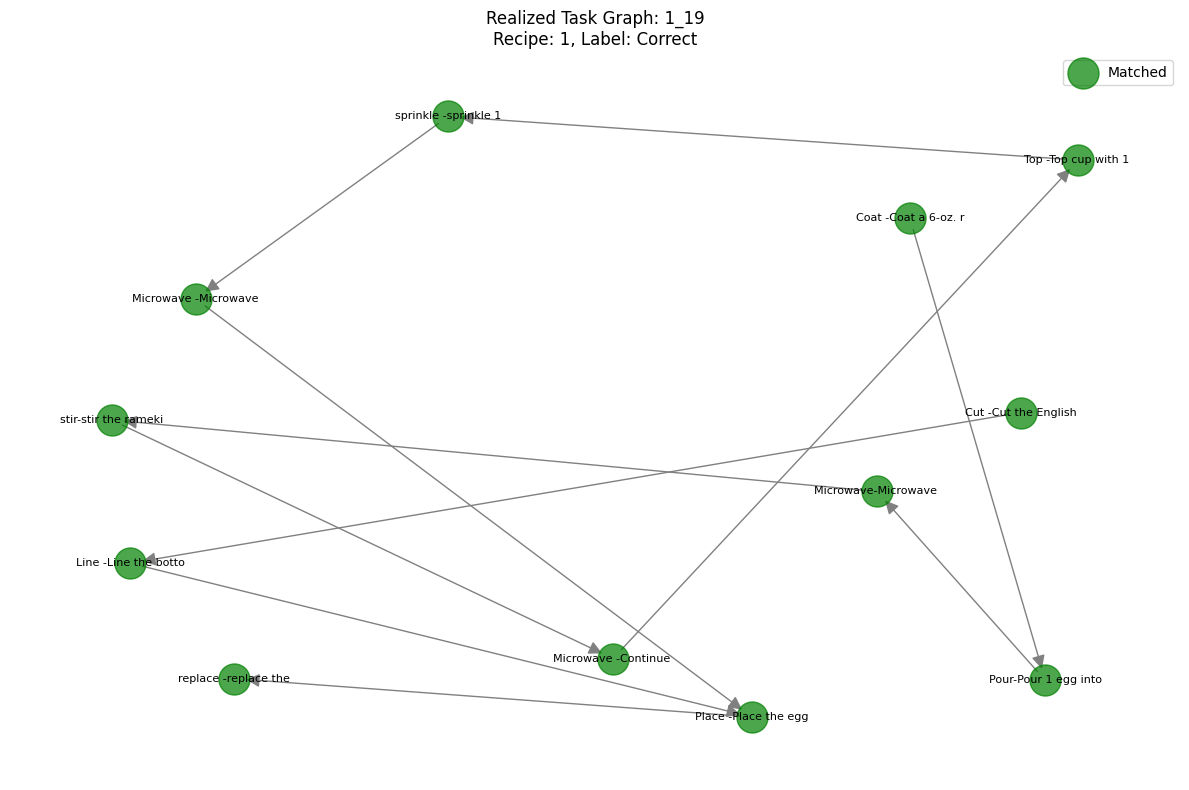

In [15]:
try:
    import networkx as nx

    # Visualize a sample realized graph
    sample_id = list(realized_graphs.keys())[0]
    sample_graph = realized_graphs[sample_id]
    sample_recipe = sample_graph['recipe_id']

    # Create NetworkX graph
    G = nx.DiGraph()

    nodes = task_graph_embeddings[sample_recipe]['nodes']
    for i, node in enumerate(nodes):
        matched = sample_graph['node_matched'][i]
        sim = sample_graph['match_similarities'][i]
        G.add_node(i, label=node['description'][:20], matched=matched, sim=sim)

    for edge in task_graph_embeddings[sample_recipe]['edges']:
        G.add_edge(edge['from'], edge['to'])

    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))

    pos = nx.spring_layout(G, k=2)

    # Color nodes by match status
    matched_nodes = [n for n in G.nodes() if G.nodes[n]['matched']]
    unmatched_nodes = [n for n in G.nodes() if not G.nodes[n]['matched']]

    nx.draw_networkx_nodes(G, pos, nodelist=matched_nodes, node_color='green',
                           node_size=500, alpha=0.7, label='Matched')
    nx.draw_networkx_nodes(G, pos, nodelist=unmatched_nodes, node_color='red',
                           node_size=500, alpha=0.7, label='Unmatched')

    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)

    labels = {n: G.nodes[n]['label'] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    plt.title(f"Realized Task Graph: {sample_id}\nRecipe: {sample_recipe}, Label: {'Incorrect' if sample_graph['recipe_label'] else 'Correct'}")
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('extension_data/sample_realized_graph.png', dpi=150)
    plt.show()

except ImportError:
    print("NetworkX not installed. Skip graph visualization.")

## Summary

In this notebook, we completed **Substep 3: Task-Graph Encoding + Step Matching**:

1. Built task graphs from step annotations (24 recipe types)
2. Encoded task graph nodes with the **EgoVLP text encoder**, so that node embeddings
   share a space with the visual step embeddings from Substep 1
3. **Verified that shared space instead of assuming it** (diagnostic cell in Section 2)
4. Matched visual steps to graph nodes with the Hungarian algorithm
5. Stored text and visual node features separately for the learnable projection in
   Substep 4, plus a fixed-average baseline
6. Saved the realized graphs

**Why the EgoVLP text encoder**: the spec requires it because EgoVLP's text and video
towers are jointly trained and therefore aligned, which is what makes a raw cosine
similarity between a video segment and a step description meaningful. Any other text
encoder (e.g. plain DistilBERT) would sit in an unrelated space and would need a
projection learned from scratch.

**Verifying that claim**: `load_state_dict(..., strict=False)` silently leaves any
parameter missing from the checkpoint randomly initialised, so "the encoder loaded" is
not evidence the *aligned* head loaded. The diagnostic checks both: the checkpoint
matches the model exactly (0 missing, 0 unexpected keys), and video->text retrieval of
each recording's own step descriptions reaches **27.31% top-1 against a 7.15% chance
rate**, with matched pairs scoring **+0.112** cosine above mismatched pairs. The
alignment is real but far from perfect, which is the honest characterisation of the
matching quality this extension is built on.

**Key observations**:
- Hungarian matching gives an optimal one-to-one assignment under that similarity
- Unmatched nodes correspond to steps the task graph expects but the video never shows,
  which is a direct signal for missed steps
- Mean match similarity alone does **not** separate correct from incorrect executions
  (0.367 vs 0.374). This is expected rather than a defect: CaptainCook4D errors are
  mostly wrong temperature, wrong quantity or a missing step, which barely change how
  much the performed steps look like their descriptions. The usable signal is in the
  per-node features and the unmatched mask, which is what the GNN consumes.

**Next**: **Substep 4** - GNN classification of the realized task graph, where the
learnable projection is trained end-to-end with the classification loss.